In [1]:
# ERT Field data with topography 
# colorMap is Spectral_r for all diagrams 

In [2]:
# studying a slagdump - A slag dump is a designated area where molten or solid byproduct (slag) from metal smelting, primarily steel and iron production, is deposited

In [3]:
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics import ert 

In [4]:
data = pg.getExampleData('ert/slagdump.ohm', verbose=True)
print(data)

# pg.getExampleData is the link between the official repo of pygimli and our local system 

05/05/26 - 19:40:14 - pyGIMLi - INFO - Looking for ert/slagdump.ohm in gimli-org/example-data/
05/05/26 - 19:40:14 - pyGIMLi - INFO - File already exists: C:\Users\anves\AppData\Roaming\pygimli\Cache\example-data\gimli-org/example-data/master\ert/slagdump.ohm
05/05/26 - 19:40:14 - pyGIMLi - INFO - Reading C:\Users\anves\AppData\Roaming\pygimli\Cache\example-data\gimli-org/example-data/master\ert/slagdump.ohm (<class 'pgcore.libs._pygimli_.DataContainerERT'>)


Data: Sensors: 38 data: 222, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']


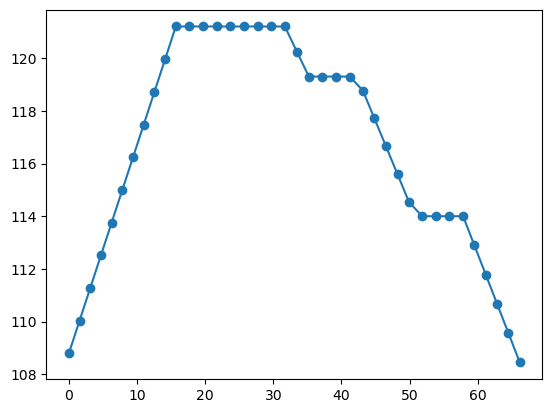

In [5]:
plt.plot(pg.x(data), pg.z(data), 'o-')

# to visualize our electrode geometry 
# x axis looks at horizontal dist
# z axis is for seeing topography ! 
# x- is for drawing the graph -> puts a little x mark at every point, connects them with dashes 

In [6]:
# the above diagram is the topographical profile of the site 
# along x axis its about 67 m 
# vertical axis shows distance from mean sea level 
# this hill shape is the piece of elevated land we are working with 
# every blue dot is an electrode 

05/05/26 - 19:40:15 - pyGIMLi - INFO - Cache C:\Users\anves\anaconda3\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 2): C:\Users\anves\AppData\Roaming\pygimli\Cache\7934726207905526713
05/05/26 - 19:40:15 - pyGIMLi - INFO - Cache C:\Users\anves\anaconda3\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (2.7s x 4): C:\Users\anves\AppData\Roaming\pygimli\Cache\962514708867524580


222 [25.13257921442133,...,297.72862487080533] 222 [13.821456394830763,...,155.97955859655056]


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x28e106f2cf0>)

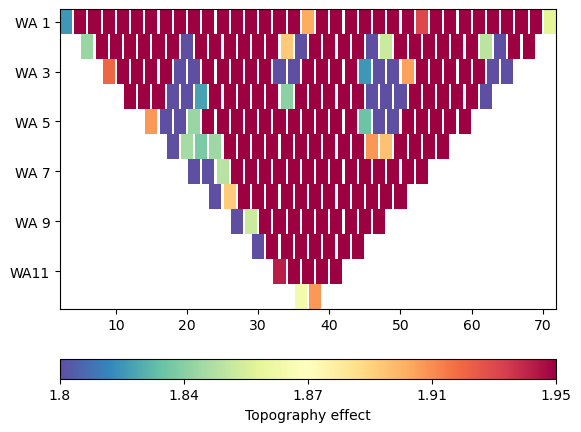

In [7]:
# our dataset contains values of R.. but pg.show() requires rhoa (resisitivity) values

k0 = ert.createGeometricFactors(data)  # the analytical one
# flat land data 

data['k'] = ert.createGeometricFactors(data, numerical=True)
# numerical = True mentioned bc by default its taken as a flat land 

print(k0, data['k'])

ert.showData(data, vals=k0/data['k'], label='Topography effect', cMin=1.8, cMax=1.95, logScale=True, colorMap="Spectral_r")
# we are displaying effect of topography at each point
# by calc error (k0/data[k]) -> a value of 1 means not much effect of terrain and more or less then 1 indicates elevation 
# cmin and cmax is max and min values in the scale.. we took is as 0.67-1.5 so that 1 is around in between always 

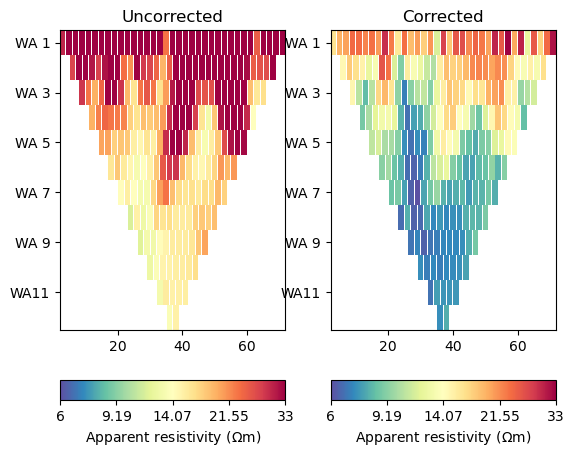

In [8]:
# plotting graph with flat land data and altitude data 
data['rhoa'] = data['r'] * data['k']
kw = dict(cMin=6, cMax=33) # dict of color scale for both graphs should be same 
fig, ax = plt.subplots(ncols=2)
data.show(data['r']*k0, ax=ax[0], **kw);
data.show(data['rhoa'], ax=ax[1], **kw)
ax[0].set_title('Uncorrected')
ax[1].set_title('Corrected');


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x28e10e97750>)

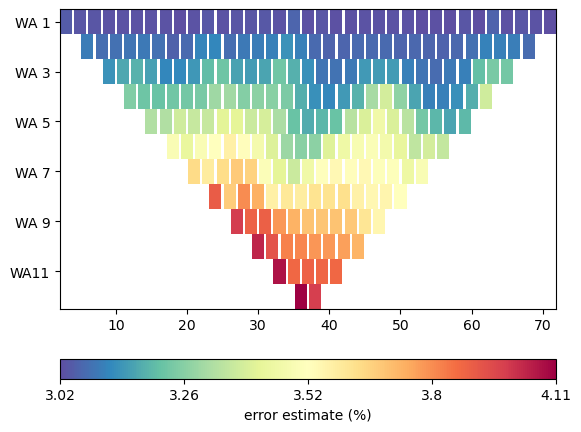

In [9]:
# noise quantification 
data.estimateError(relativeError=0.03, absoluteUError=5e-5) # absError added (noise)
data.show(data['err']*100, label='error estimate (%)') #data['err'] -> pygimli stores the error for each cell 

In [10]:
# reverse modelling (inversion)

05/05/26 - 19:41:44 - pyGIMLi - INFO - Found 2 regions.
05/05/26 - 19:41:44 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
05/05/26 - 19:41:44 - pyGIMLi - INFO - Found 2 regions.
05/05/26 - 19:41:44 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
05/05/26 - 19:41:44 - pyGIMLi - INFO - Creating forward mesh from region infos.
05/05/26 - 19:41:44 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
05/05/26 - 19:41:44 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3406 Cells: 6492 Boundaries: 5028
05/05/26 - 19:41:44 - pyGIMLi - INFO - Use median(data values)=10.648608361317056
05/05/26 - 19:41:44 - pyGIMLi - INFO - Created startmodel from forward operator:1029, min/max=10.648608/10.648608
05/05/26 - 19:41:44 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000028DCE6C8EF0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 6.07/33.48
min/max (error): 3.02%/4.11%
min/max (start model): 10.65/10.65
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  198.11
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   16.04 (dPhi = 90.58%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    1.27 (dPhi = 81.89%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    0.83 (dPhi = 10.19%) lam: 10.0


################################################################################
#                  Abort criterion reached: chi² <= 1 (0.83)                   #
#################

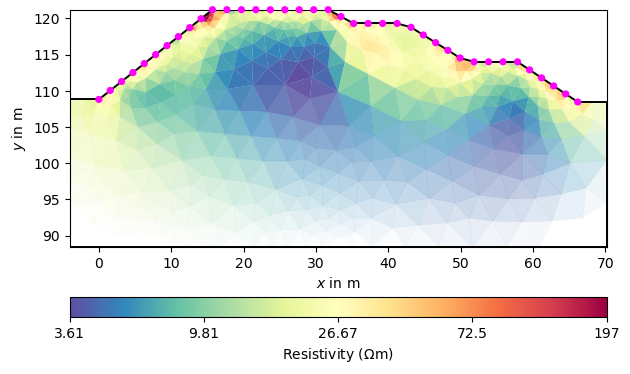

In [13]:
mgr = ert.ERTManager(data)
mod = mgr.invert(data, lam=10, verbose=True,
                 paraDX=0.3, paraMaxCellSize=10, paraDepth=20, quality=33.6, colorMap="Spectral_r")
ax, cb = mgr.showResult()

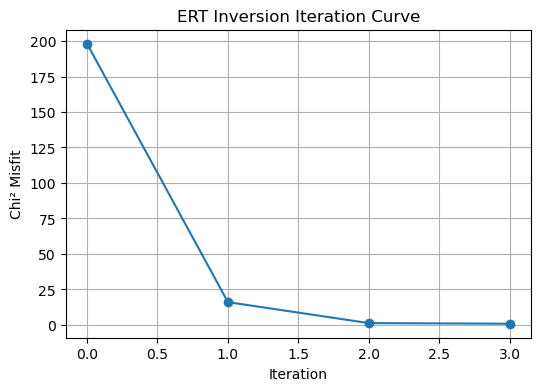

In [14]:
inversion = mgr.inv
chi2=inversion.chi2History
plt.figure(figsize=(6,4))
plt.plot(chi2, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Chi² Misfit")
plt.title("ERT Inversion Iteration Curve")
plt.grid(True)